# Libs

In [100]:
import os
import sys

from FiberTrackingAnalysisFunctions import *

# Dipy
import dipy as dp
from dipy.io.image import load_nifti, save_nifti
from dipy.io import read_bvals_bvecs
from dipy.core.gradients import gradient_table
import dipy.data as dpd
from dipy.tracking import utils

#Preproc
from dipy.align import motion_correction
import dipy.direction.peaks as dpp
#from dipy.viz import window, actor
from dipy.segment.mask import median_otsu
from dipy.core.histeq import histeq


#DIPY Plot
from dipy.viz import window, actor, colormap
from dipy.data import get_sphere, default_sphere, get_fnames

#Regular Packages
import keyboard  # For detecting keypresses
import IPython
import pickle #loading pkl files (dictonairy)
import pandas as pd


import numpy as np
from pathlib import Path
from time import time
import time  # For simulating work
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import scipy.io

#Plot packages
import napari

#Model Packages
from dipy.direction import peaks_from_model
from dipy.reconst.dti import color_fa
from dipy.reconst.csdeconv import auto_response_ssst
from dipy.reconst.dti import TensorModel
from dipy.reconst.shm import CsaOdfModel
import dipy.reconst.sfm as sfm
import dipy.reconst.dki as dki
import dipy.reconst.dti as dti
from dipy.tracking.stopping_criterion import (ActStoppingCriterion,
                                              BinaryStoppingCriterion,
                                              ThresholdStoppingCriterion)


segment_info = {
    "C1":  {"pct": 1.6, "cum_pct": 1.6},
    "C2":  {"pct": 2.2, "cum_pct": 3.9},
    "C3":  {"pct": 3.5, "cum_pct": 7.3},
    "C4":  {"pct": 3.5, "cum_pct": 10.8},
    "C5":  {"pct": 3.5, "cum_pct": 14.3},
    "C6":  {"pct": 3.3, "cum_pct": 17.6},
    "C7":  {"pct": 3.2, "cum_pct": 20.8},
    "C8":  {"pct": 3.4, "cum_pct": 24.1},
    "T1":  {"pct": 3.6, "cum_pct": 27.7},
    "T2":  {"pct": 3.9, "cum_pct": 31.6},
    "T3":  {"pct": 4.4, "cum_pct": 36.0},
    "T4":  {"pct": 5.0, "cum_pct": 41.0},
    "T5":  {"pct": 5.1, "cum_pct": 46.1},
    "T6":  {"pct": 5.6, "cum_pct": 51.8},
    "T7":  {"pct": 5.6, "cum_pct": 57.4},
    "T8":  {"pct": 5.4, "cum_pct": 62.7},
    "T9":  {"pct": 5.1, "cum_pct": 67.8},
    "T10": {"pct": 4.7, "cum_pct": 72.4},
    "T11": {"pct": 4.3, "cum_pct": 76.7},
    "T12": {"pct": 3.9, "cum_pct": 80.6},
    "L1":  {"pct": 3.6, "cum_pct": 84.2},
    "L2":  {"pct": 2.8, "cum_pct": 87.0},
    "L3":  {"pct": 2.4, "cum_pct": 89.4},
    "L4":  {"pct": 2.2, "cum_pct": 91.6},
    "L5":  {"pct": 1.7, "cum_pct": 93.3},
    "S1":  {"pct": 1.5, "cum_pct": 94.9},
    "S2":  {"pct": 1.6, "cum_pct": 96.4},
    "S3":  {"pct": 1.4, "cum_pct": 97.8},
    "S4":  {"pct": 1.3, "cum_pct": 99.1},
    "S5":  {"pct": 0.9, "cum_pct": 100.0},
}
segment_cum_pct = {
    "C1": 1.6, "C2": 3.9, "C3": 7.3, "C4": 10.8, "C5": 14.3, "C6": 17.6, "C7": 20.8, "C8": 24.1,
    "T1": 27.7, "T2": 31.6, "T3": 36.0, "T4": 41.0, "T5": 46.1, "T6": 51.8, "T7": 57.4, "T8": 62.7,
    "T9": 67.8, "T10": 72.4, "T11": 76.7, "T12": 80.6,
    "L1": 84.2, "L2": 87.0, "L3": 89.4, "L4": 91.6, "L5": 93.3,
    "S1": 94.9, "S2": 96.4, "S3": 97.8, "S4": 99.1, "S5": 100.0,
}

min_z = 10
max_z = -150
t2, affine_t2 = load_nifti("Data/Rotated and Transposed/RARE_combined_trans_denoised_gibbs_masked_rotated_BFC_corrected20.nii.gz")
t2 = t2[:,:,min_z:max_z]

# Calculate actual z-index for all spinal segments using cum_pct and t2 z-dimension
z_dim = t2.shape[2]
segment_z_index = {}

for seg, info in segment_info.items():
    cum_pct = info["cum_pct"]
    z_idx = int(round((cum_pct / 100) * (z_dim - 1)))
    segment_z_index[seg] = z_idx

print(segment_z_index)

{'C1': 29, 'C2': 70, 'C3': 132, 'C4': 195, 'C5': 258, 'C6': 318, 'C7': 375, 'C8': 435, 'T1': 500, 'T2': 570, 'T3': 649, 'T4': 740, 'T5': 832, 'T6': 934, 'T7': 1035, 'T8': 1131, 'T9': 1223, 'T10': 1306, 'T11': 1384, 'T12': 1454, 'L1': 1519, 'L2': 1569, 'L3': 1613, 'L4': 1652, 'L5': 1683, 'S1': 1712, 'S2': 1739, 'S3': 1764, 'S4': 1788, 'S5': 1804}


# Basic Deterministic Tracking

In [2]:
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames
from dipy.direction import peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.stateful_tractogram import Space, StatefulTractogram
from dipy.io.streamline import save_trk
from dipy.reconst.shm import CsaOdfModel
from dipy.tracking import utils
from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
from dipy.tracking.streamline import Streamlines
from dipy.tracking.tracker import eudx_tracking
from dipy.viz import actor, colormap, has_fury, window

shape t2: (384, 384, 1805)
shape DTI: (96, 96, 1805, 83)


/tmp/ipykernel_193077/2307996874.py:48: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


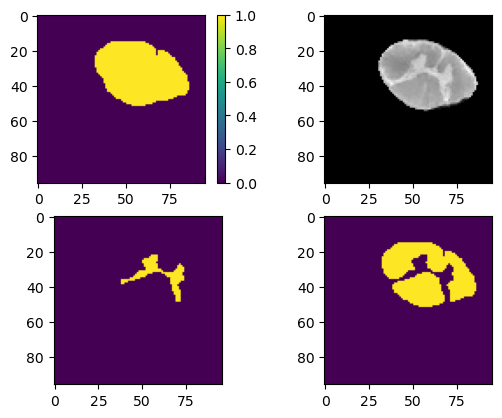

In [3]:
# Load in Data
DTI_trans_corrected , DTI_Affine_all = load_nifti("Data/Transposed/DTI_combined_preproc_trans_masked_BFC_corrected20.nii.gz")
DTI_trans_corrected = DTI_trans_corrected[:,:,min_z:max_z,:]
DTI_trans, DTI_affine = load_nifti("Data/Transposed/DTI_combined_preproc_trans_masked.nii.gz")
DTI_trans = DTI_trans[:,:,min_z:max_z, :]


# T2
t2_trans, t2_affine = load_nifti("Data/Transposed/RARE_combined_trans_denoised_gibbs_masked_BFC_corrected20.nii.gz")
t2_trans =  t2_trans [: ,: ,min_z:max_z]

t2_trans_in_b0, t2_b0_affine = load_nifti("Data/Transposed/T2_in_DWI.nii.gz")
t2_trans_in_b0 = t2_trans_in_b0[:,:,min_z:max_z]



print(f"shape t2: {t2_trans.shape}")
print(f"shape DTI: {DTI_trans_corrected.shape}")

## Load GM Mask 
gm_wm_mask_path_trans = "Data/Transposed/Combined_GM_WM_mask_aug_FINAL_f1_threshold_dilated_96x96.npy" 
mask_gm_wm_trans = np.load(gm_wm_mask_path_trans).squeeze()
mask_gm_wm_trans = np.transpose(mask_gm_wm_trans, (2, 1, 0))
mask_gm_wm_trans = np.flip(mask_gm_wm_trans, axis=0)
mask_gm_wm_trans = mask_gm_wm_trans[:,:,min_z:max_z]


# Generate WM and GM masks from gm_wm_mask
mask_gm_trans = (mask_gm_wm_trans == 1).astype(bool)
mask_wm_trans = (mask_gm_wm_trans == 2).astype(bool)
mask_gm_wm_trans_final = np.where(mask_gm_wm_trans == 1, 1, np.where(mask_gm_wm_trans == 2, 1, 0)).astype(bool)


plt.subplot(2,2,1)
plt.imshow(mask_gm_wm_trans_final[:,:,50])
plt.colorbar()
plt.subplot(2,2,2)
plt.imshow(DTI_trans[:,:,50,0], cmap='gray')
plt.subplot(2,2,3)
plt.imshow(mask_gm_trans[:,:,50])
plt.subplot(2,2,4)
plt.imshow(mask_wm_trans[:,:,50])

#bvecs and bvals
fbval = 'Data/bval.txt'
fbvec = 'Data/MPG80_bvec.txt'
bvals, bvecs = read_bvals_bvecs(fbval, fbvec)
gtab = gradient_table(bvals, bvecs)

rotation_data = np.load("Data/Rotated and Transposed/complete_coordinates_of_lines_for_rotation.pkl", allow_pickle=True)
rotation_angle = rotation_data["smoothed_angle"][min_z:max_z]

plot_idx_dict ={"C4": 238,
 "T6": 945,
 "L2": 1560,
 "S3": 1742}


In [4]:
csa_model = CsaOdfModel(gtab, sh_order_max=6)
csa_peaks = peaks_from_model(
    csa_model,
    DTI_trans_corrected,
    default_sphere,
    relative_peak_threshold=0.8,
    min_separation_angle=45,
    mask=mask_gm_wm_trans_final,
)

In [6]:
### Visualize Peaks
interactive = False
if has_fury:
    scene = window.Scene()
    scene.add(
        actor.peak_slicer(
            csa_peaks.peak_dirs, peaks_values=csa_peaks.peak_values
        )
    )

    window.record(scene=scene, out_path="Figures/Test/csa_direction_field.png", size=(900, 900))

    if interactive:
        window.show(scene, size=(800, 800))

In [12]:
stopping_criterion = ThresholdStoppingCriterion(csa_peaks.gfa, 0.25)

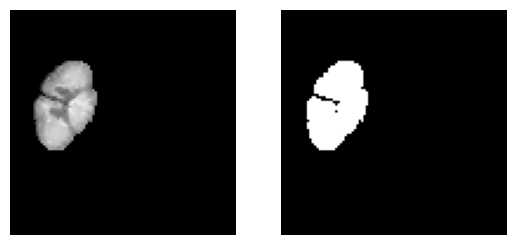

In [13]:
sli = csa_peaks.gfa.shape[2] // 2
plt.figure("GFA")
plt.subplot(1, 2, 1).set_axis_off()
plt.imshow(csa_peaks.gfa[:, :, sli].T, cmap="gray", origin="lower")

plt.subplot(1, 2, 2).set_axis_off()
plt.imshow((csa_peaks.gfa[:, :, sli] > 0.25).T, cmap="gray", origin="lower")

#plt.savefig("gfa_tracking_mask.png")

In [15]:
seed_mask = mask_gm_wm_trans == 1
seeds = utils.seeds_from_mask(seed_mask, DTI_Affine_all, density=[2, 2, 2])

In [19]:
# Initialization of eudx_tracking. The computation happens in the next step.
streamlines_generator = eudx_tracking(
    seeds, stopping_criterion, DTI_Affine_all, step_size=0.5, pam=csa_peaks
)
# Generate streamlines object
streamlines = Streamlines(streamlines_generator)

In [35]:
if has_fury:
    # Prepare the display objects.
    color = colormap.line_colors(streamlines)

    streamlines_actor = actor.line(
        streamlines, colors=colormap.line_colors(streamlines)
    )
    scene.reset_camera()
    # Create the 3D display.
    scene = window.Scene()
    scene.add(streamlines_actor)

    # Save still images for this static example. Or for interactivity use
    window.record(scene=scene, out_path="Figures/Test/tractogram_EuDX.png", size=(3000,3000))

In [31]:
import nibabel as nib

DTI_img = nib.Nifti1Image(
    DTI_trans_corrected,
    DTI_Affine_all
)


In [33]:
sft = StatefulTractogram(streamlines = streamlines, reference = DTI_img, space = Space.RASMM)
save_trk(sft, "Data/ractogram_EuDX.trk", streamlines)

# Probablisitic Tracking

In [2]:
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames
from dipy.direction import peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, load_nifti_data
from dipy.io.stateful_tractogram import Space, StatefulTractogram
from dipy.io.streamline import save_trk
from dipy.reconst.csdeconv import ConstrainedSphericalDeconvModel, auto_response_ssst
from dipy.tracking.stopping_criterion import BinaryStoppingCriterion
from dipy.tracking.streamline import Streamlines
from dipy.tracking.tracker import probabilistic_tracking
from dipy.tracking.utils import seeds_from_mask
from dipy.viz import actor, colormap, has_fury, window


shape t2: (384, 384, 1805)
shape DTI: (96, 96, 1805, 83)


/tmp/ipykernel_214874/2307996874.py:48: UserWarning: Pass ['bvecs'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  gtab = gradient_table(bvals, bvecs)


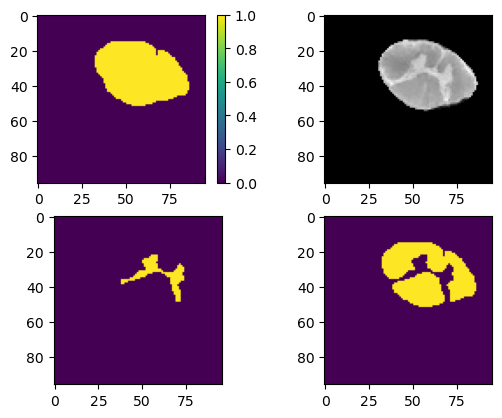

In [3]:
# Load in Data
DTI_trans_corrected , DTI_Affine_all = load_nifti("Data/Transposed/DTI_combined_preproc_trans_masked_BFC_corrected20.nii.gz")
DTI_trans_corrected = DTI_trans_corrected[:,:,min_z:max_z,:]
DTI_trans, DTI_affine = load_nifti("Data/Transposed/DTI_combined_preproc_trans_masked.nii.gz")
DTI_trans = DTI_trans[:,:,min_z:max_z, :]


# T2
t2_trans, t2_affine = load_nifti("Data/Transposed/RARE_combined_trans_denoised_gibbs_masked_BFC_corrected20.nii.gz")
t2_trans =  t2_trans [: ,: ,min_z:max_z]

t2_trans_in_b0, t2_b0_affine = load_nifti("Data/Transposed/T2_in_DWI.nii.gz")
t2_trans_in_b0 = t2_trans_in_b0[:,:,min_z:max_z]



print(f"shape t2: {t2_trans.shape}")
print(f"shape DTI: {DTI_trans_corrected.shape}")

## Load GM Mask 
gm_wm_mask_path_trans = "Data/Transposed/Combined_GM_WM_mask_aug_FINAL_f1_threshold_dilated_96x96.npy" 
mask_gm_wm_trans = np.load(gm_wm_mask_path_trans).squeeze()
mask_gm_wm_trans = np.transpose(mask_gm_wm_trans, (2, 1, 0))
mask_gm_wm_trans = np.flip(mask_gm_wm_trans, axis=0)
mask_gm_wm_trans = mask_gm_wm_trans[:,:,min_z:max_z]


# Generate WM and GM masks from gm_wm_mask
mask_gm_trans = (mask_gm_wm_trans == 1).astype(bool)
mask_wm_trans = (mask_gm_wm_trans == 2).astype(bool)
mask_gm_wm_trans_final = np.where(mask_gm_wm_trans == 1, 1, np.where(mask_gm_wm_trans == 2, 1, 0)).astype(bool)


plt.subplot(2,2,1)
plt.imshow(mask_gm_wm_trans_final[:,:,50])
plt.colorbar()
plt.subplot(2,2,2)
plt.imshow(DTI_trans[:,:,50,0], cmap='gray')
plt.subplot(2,2,3)
plt.imshow(mask_gm_trans[:,:,50])
plt.subplot(2,2,4)
plt.imshow(mask_wm_trans[:,:,50])

#bvecs and bvals
fbval = 'Data/bval.txt'
fbvec = 'Data/MPG80_bvec.txt'
bvals, bvecs = read_bvals_bvecs(fbval, fbvec)
gtab = gradient_table(bvals, bvecs)

rotation_data = np.load("Data/Rotated and Transposed/complete_coordinates_of_lines_for_rotation.pkl", allow_pickle=True)
rotation_angle = rotation_data["smoothed_angle"][min_z:max_z]

plot_idx_dict ={"C4": 238,
 "T6": 945,
 "L2": 1560,
 "S3": 1742}


In [4]:
from dipy.tracking.utils import seeds_from_mask
from dipy.reconst.csdeconv import response_from_mask_ssst

#GM
seeds_gm = seeds_from_mask(
    mask_gm_trans,
    density = 3,   # seeds per voxel
    affine = DTI_Affine_all)
sc_gm = BinaryStoppingCriterion(mask_gm_trans)

#WM 
seeds_wm = seeds_from_mask(mask_wm_trans, DTI_Affine_all, density=4)
sc_wm = BinaryStoppingCriterion(mask_wm_trans)

response_wm_trans, ratio_wm = response_from_mask_ssst(gtab, DTI_trans_corrected, mask_wm_trans)


In [ ]:
#Model 
csd_model = ConstrainedSphericalDeconvModel(gtab, response_wm_trans,
                                             sh_order_max = 8)
csd_fit = csd_model.fit(DTI_trans_corrected, mask = mask_gm_wm_trans_final)

In [ ]:
sphere = get_sphere(name="symmetric362")
fod = csd_fit.odf(sphere)
streamline_generator_gm = probabilistic_tracking(
    seed_positions = seeds_gm,
    sc = sc_gm,
    affine = DTI_Affine_all,
    sf=fod,
    random_seed = 1,
    sphere = default_sphere, 
    max_angle = 45, # THIS SHULD BE OPIMIZED  
    step_size=0.2,
    save_seeds = True # # This should be optimized Step size is in mm as we pass the DTI_Affine_all to transform the coordinates to RASMM space. 
)

### Save As Streamlines Object and Seeds used for tracking
streamlines = []
seeds_used = []

for sl, seed in streamline_generator_gm:
    streamlines.append(sl)
    seeds_used.append(seed)

streamlines_gm = Streamlines(streamlines)
seeds_used = np.asarray(seeds_used)

assert len(streamlines_gm) == len(seeds_used)
if len(streamlines_gm) == len(seeds_used):
    # Save the Tractography
    import nibabel as nib
    DTI_img = nib.Nifti1Image(
        DTI_trans_corrected,
        DTI_Affine_all)
    
    sft_gm = StatefulTractogram(streamlines_gm, DTI_img, Space.RASMM)
    sft_gm.data_per_streamline["seeds"] = seeds_used
    save_trk(sft_gm, "Data/tractogram_probabilistic_gm_with_seeds_sf.trk")

In [ ]:
# save Image
if has_fury:
    scene = window.Scene()
    scene.add(actor.line(streamlines_gm, fake_tube = True ,colors=colormap.line_colors(streamlines_gm)))
    window.record(
        scene=scene, out_path="Figures/Test/tractogram_probabilistic_gm_with_seeds_sf.png", size=(3000, 3000)
    )


In [ ]:
#### WM 
fod = csd_fit.odf(default_sphere)
streamline_generator_wm = probabilistic_tracking(
    seed_positions = seeds_wm,
    sc = sc_wm,
    affine = DTI_Affine_all,
    sf=fod,
    random_seed=1,
    sphere=default_sphere,
    max_angle=25,
    step_size=0.2, # Step size is in mm as we pass the DTI_Affine_all to transform the coordinates to RASMM space. 
)

import nibabel as nib

DTI_img = nib.Nifti1Image(
    DTI_trans_corrected,
    DTI_Affine_all
)

streamlines_wm = Streamlines(streamline_generator_wm)
sft_wm = StatefulTractogram(streamlines_wm, DTI_img, Space.RASMM)
save_trk(sft_wm, "Data/tractogram_probabilistic_wm_sf.trk")

if has_fury:
    scene = window.Scene()
    scene.reset_camera()
    scene
    scene.active_camera.zoom(3)
    scene.add(actor.line(streamlines_wm, fake_tube = True ,colors=colormap.line_colors(streamlines_wm)))
    window.record(
        scene=scene, out_path="Figure/Test/tractogram_probabilistic_wm_sf.png", size=(3000, 3000)
    )



## Analyze The Tracking

In [114]:
segment_z_index

{'C1': 29,
 'C2': 70,
 'C3': 132,
 'C4': 195,
 'C5': 258,
 'C6': 318,
 'C7': 375,
 'C8': 435,
 'T1': 500,
 'T2': 570,
 'T3': 649,
 'T4': 740,
 'T5': 832,
 'T6': 934,
 'T7': 1035,
 'T8': 1131,
 'T9': 1223,
 'T10': 1306,
 'T11': 1384,
 'T12': 1454,
 'L1': 1519,
 'L2': 1569,
 'L3': 1613,
 'L4': 1652,
 'L5': 1683,
 'S1': 1712,
 'S2': 1739,
 'S3': 1764,
 'S4': 1788,
 'S5': 1804}

In [126]:

## Cervical
streamlines_seed_filtered_cervical = filter_streamlines_by_seed_z(sft= sft_gm, affine = DTI_Affine_all, 
                                                              z_min_vox = 195, z_max_vox =  195)

length_filtered_streamlines_seed_filtered_cervical, lengths_cervical, mask_cervical =  select_by_length(streamlines_seed_filtered_cervical, min_length=2.5, max_length=200)

In [127]:

## Thoracic
streamlines_seed_filtered_thoracic = filter_streamlines_by_seed_z(sft= sft_gm, affine = DTI_Affine_all, 
                                                              z_min_vox = 655, z_max_vox =  655)

length_filtered_streamlines_seed_filtered_thoracic, lengths_thoracic, mask_thoracic =  select_by_length(streamlines_seed_filtered_thoracic, min_length=2.5, max_length=200)

In [128]:

## Lumbar
streamlines_seed_filtered_lumbar = filter_streamlines_by_seed_z(sft= sft_gm, affine = DTI_Affine_all, 
                                                              z_min_vox = 1645, z_max_vox =  1645)

length_filtered_streamlines_seed_filtered_lumbar, lengths_lumbar, mask_lumbar =  select_by_length(streamlines_seed_filtered_lumbar, min_length=2.5, max_length=200)

In [129]:

## Sacral
streamlines_seed_filtered_sacral = filter_streamlines_by_seed_z(sft= sft_gm, affine = DTI_Affine_all, 
                                                              z_min_vox = 1765, z_max_vox =  1765)

length_filtered_streamlines_seed_filtered_sacral, lengths_sacral, mask_sacral =  select_by_length(streamlines_seed_filtered_sacral, min_length=2.5, max_length=200)

In [140]:
def visualize_streamlines_stats(filtered_streamlines, filtered_lengths, plot_each = False, summary_title=None, fig_save_path = None):
    
    # ============================================================
    # 1. LENGTH ANALYSIS
    # ============================================================
    # Get length of every streamline in mm
    print(f"Number of streamlines:  {len(filtered_streamlines)}")
    print(f"Mean length:            {filtered_lengths.mean():.2f} mm")
    print(f"Median length:          {np.median(filtered_lengths):.2f} mm")
    print(f"Min length:             {filtered_lengths.min():.2f} mm")
    print(f"Max length:             {filtered_lengths.max():.2f} mm")
    print(f"Std length:             {filtered_lengths.std():.2f} mm")

    # Filter by length if needed (e.g. remove short spurious streamlines)
    print(f"Streamlines after length filter: {len(filtered_streamlines)}")

    # ============================================================
    # 2. ORIENTATION ANALYSIS (per-segment)
    # ============================================================
    segment_orientations = compute_segment_orientations(filtered_streamlines)

    # Flatten all segment directions into one array for global stats
    all_directions = np.vstack(segment_orientations)  # (total_segments, 3)

    # Mean direction (note: orientations are sign-ambiguous, so flip if needed)
    mean_dir = all_directions.mean(axis=0)
    mean_dir = mean_dir / np.linalg.norm(mean_dir)
    print(f"\nMean segment direction (unit): {mean_dir}")


    # ============================================================
    # 3. ORIENTATION DISTRIBUTION FUNCTION (ODF) — spherical histogram
    # ============================================================
    theta, phi = direction_to_spherical(all_directions)
    if plot_each == True:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Polar (theta) distribution ---
        axes[0].hist(np.degrees(theta), bins=90, color='steelblue', edgecolor='k', linewidth=0.5)
        axes[0].set_xlabel('Polar angle θ (degrees from Z)')
        axes[0].set_ylabel('Segment count')
        axes[0].set_title('Polar Angle Distribution')
        axes[0].axvline(90, color='r', linestyle='--', label='XY plane')
        axes[0].legend()

        # --- Azimuthal (phi) distribution ---
        axes[1].hist(np.degrees(phi), bins=180, color='coral', edgecolor='k', linewidth=0.5)
        axes[1].set_xlabel('Azimuthal angle φ (degrees)')
        axes[1].set_ylabel('Segment count')
        axes[1].set_title('Azimuthal Angle Distribution')

        plt.tight_layout()
        plt.savefig('orientation_distributions.png', dpi=150)
        plt.show()

    # ============================================================
    # 4. PER-STREAMLINE SUMMARY ORIENTATION
    # ============================================================
    per_streamline_dirs = streamline_mean_orientation(filtered_streamlines)


    # ============================================================
    # 5. CURVATURE ANALYSIS
    # ============================================================
    all_curvatures = np.concatenate([compute_curvature(s) for s in filtered_streamlines if len(s) >= 3])

    print(f"\nMean curvature:   {all_curvatures.mean():.4f} mm^-1")
    print(f"Median curvature: {np.median(all_curvatures):.4f} mm^-1")
    if plot_each == True:
        plt.figure(figsize=(8, 4))
        plt.hist(all_curvatures, bins=100, color='mediumseagreen', edgecolor='k', linewidth=0.5)
        plt.xlabel('Curvature (mm⁻¹)')
        plt.ylabel('Segment count')
        plt.title('Curvature Distribution')
        plt.savefig('curvature_distribution.png', dpi=150)
        plt.show()


    # ============================================================
    # 6. TORTUOSITY (ratio of streamline length to straight-line distance)
    # ============================================================
    tortuosities = compute_tortuosity(filtered_streamlines)

    print(f"\nMean tortuosity:   {tortuosities.mean():.3f}")
    print(f"Median tortuosity: {np.median(tortuosities):.3f}")
    if plot_each == True:
        plt.figure(figsize=(8, 4))
        plt.hist(tortuosities, bins=80, color='mediumpurple', edgecolor='k', linewidth=0.5)
        plt.xlabel('Tortuosity (arc length / chord length)')
        plt.ylabel('Streamline count')
        plt.title('Tortuosity Distribution')
        plt.axvline(1.0, color='r', linestyle='--', label='Perfectly straight')
        plt.legend()
        plt.savefig('tortuosity_distribution.png', dpi=150)
        plt.show()


    # ============================================================
    # 7. COMBINED SUMMARY PLOT
    # ============================================================
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.0])

    # Top row: two equal-width plots
    ax_top_left = fig.add_subplot(gs[0, 0])
    ax_top_right = fig.add_subplot(gs[0, 1])

    # --- Azimuthal (phi) distribution ---
    ax_top_left.hist(np.degrees(phi), bins=180, color='coral', edgecolor='k', linewidth=0.5)
    ax_top_left.set_xlabel('Azimuthal angle φ (degrees)')
    ax_top_left.set_ylabel('Segment count')
    ax_top_left.set_title('Azimuthal Angle Distribution')

    # --- Polar (theta) distribution ---
    ax_top_right.hist(np.degrees(theta), bins= 180, color='coral', edgecolor='k', linewidth=0.5)
    ax_top_right.set_xlabel('Polar angle θ (deg from Z)')
    ax_top_right.set_title('Segment Orientation (Polar)')
    ax_top_right.axvline(90, color='r', linestyle='--', label='XY plane')
    ax_top_right.legend()

    # Bottom row: three equal-width plots across the full width
    gs_bottom = gs[1, :].subgridspec(1, 3, wspace=0.25)
    ax_len = fig.add_subplot(gs_bottom[0, 0])
    ax_curv = fig.add_subplot(gs_bottom[0, 1])
    ax_tort = fig.add_subplot(gs_bottom[0, 2])

    # --- Streamline length distribution ---
    ax_len.hist(filtered_lengths, bins=80, color='steelblue', edgecolor='k', linewidth=0.5)
    ax_len.set_xlabel('Length (mm)')
    ax_len.set_title('Streamline Length')
    ax_len.set_xlim(0, 25)  # Assuming we filtered out streamlines > 200mm

    # --- Curvature distribution ---
    ax_curv.hist(all_curvatures, bins=100, color='mediumseagreen', edgecolor='k', linewidth=0.5)
    ax_curv.set_xlabel('Curvature (mm⁻¹)')
    ax_curv.set_title('Curvature')
    ax_curv.set_xlim(0, 4)  # Focus on lower curvature values for better visualization
    
    # --- Tortuosity distribution ---
    ax_tort.hist(tortuosities, bins=80, color='mediumpurple', edgecolor='k', linewidth=0.5)
    ax_tort.set_xlabel('Tortuosity (arc length / chord length)')
    ax_tort.set_title('Tortuosity')
    ax_tort.axvline(1.0, color='r', linestyle='--', label='Perfectly straight')
    ax_tort.set_xlim(0, 10)  # Focus on tortuosity > 1 for better visualization
    ax_tort.legend()

    plt.suptitle('Tractography Analysis Summary', fontsize=14, fontweight='bold')
    if summary_title is not None:
        plt.suptitle(summary_title, fontsize=14, fontweight='bold')

    
    plt.tight_layout()
    plt.savefig('tractography_summary.png', dpi=150)

    if fig_save_path is not None:
        plt.savefig(fig_save_path, dpi=300)
    plt.show()

Number of streamlines:  1058
Mean length:            3.60 mm
Median length:          3.20 mm
Min length:             2.60 mm
Max length:             10.40 mm
Std length:             1.10 mm
Streamlines after length filter: 1058

Mean segment direction (unit): [-0.00223879  0.92796381  0.3726636 ]

Mean curvature:   1.8362 mm^-1
Median curvature: 1.9016 mm^-1

Mean tortuosity:   1.258
Median tortuosity: 1.148


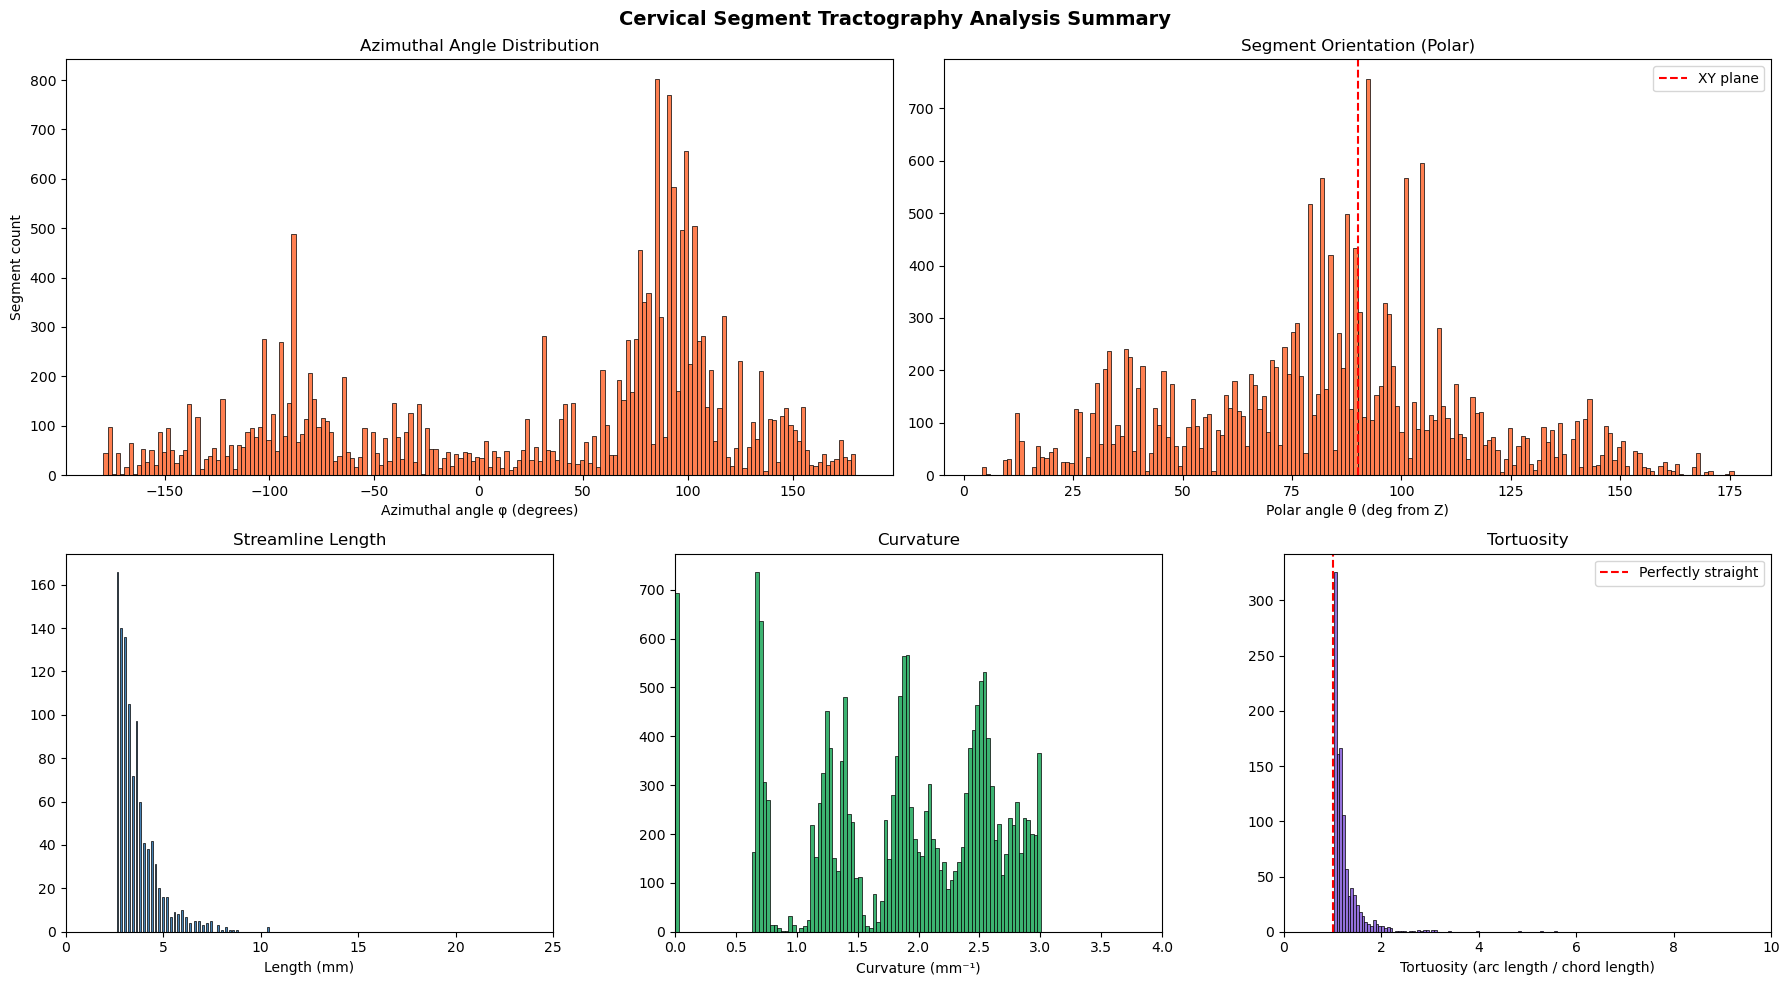

Number of streamlines:  65
Mean length:            2.89 mm
Median length:          2.80 mm
Min length:             2.60 mm
Max length:             4.20 mm
Std length:             0.34 mm
Streamlines after length filter: 65

Mean segment direction (unit): [0.02342315 0.99956709 0.01780394]

Mean curvature:   1.5971 mm^-1
Median curvature: 1.5089 mm^-1

Mean tortuosity:   1.050
Median tortuosity: 1.034


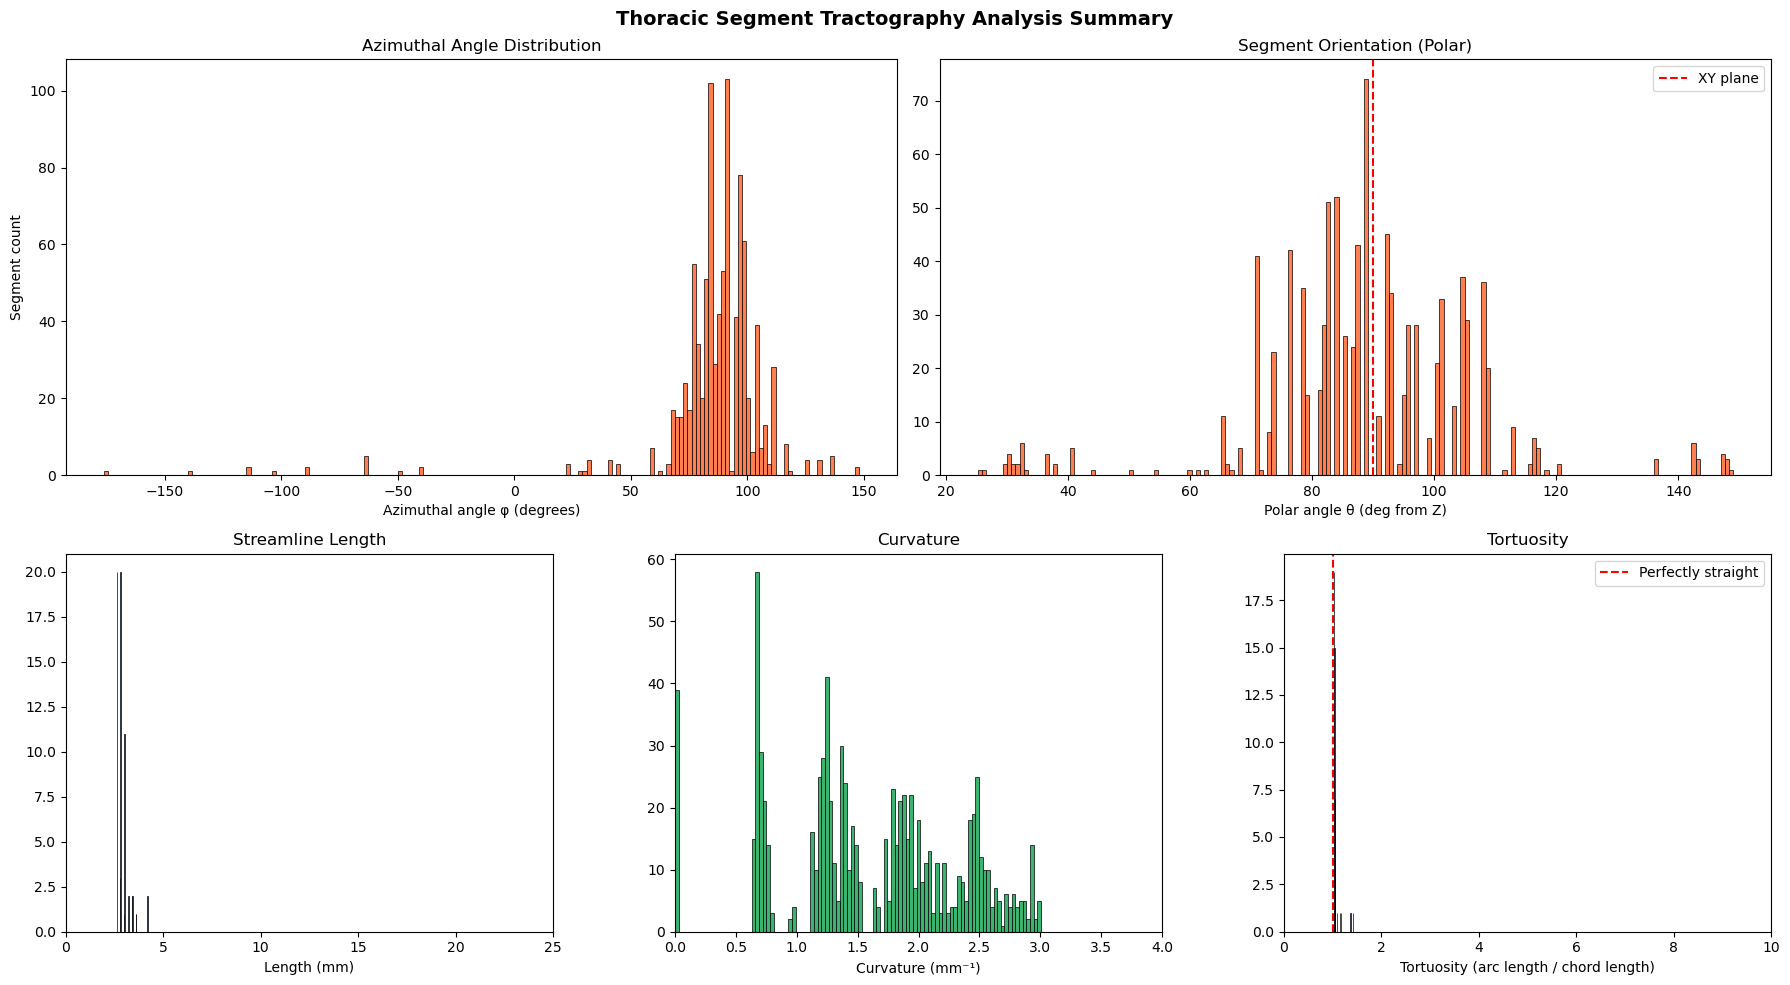

Number of streamlines:  2590
Mean length:            5.04 mm
Median length:          4.40 mm
Min length:             2.60 mm
Max length:             19.40 mm
Std length:             2.18 mm
Streamlines after length filter: 2590

Mean segment direction (unit): [-0.08581334  0.08410715  0.99275478]

Mean curvature:   1.8905 mm^-1
Median curvature: 1.9610 mm^-1

Mean tortuosity:   1.464
Median tortuosity: 1.289


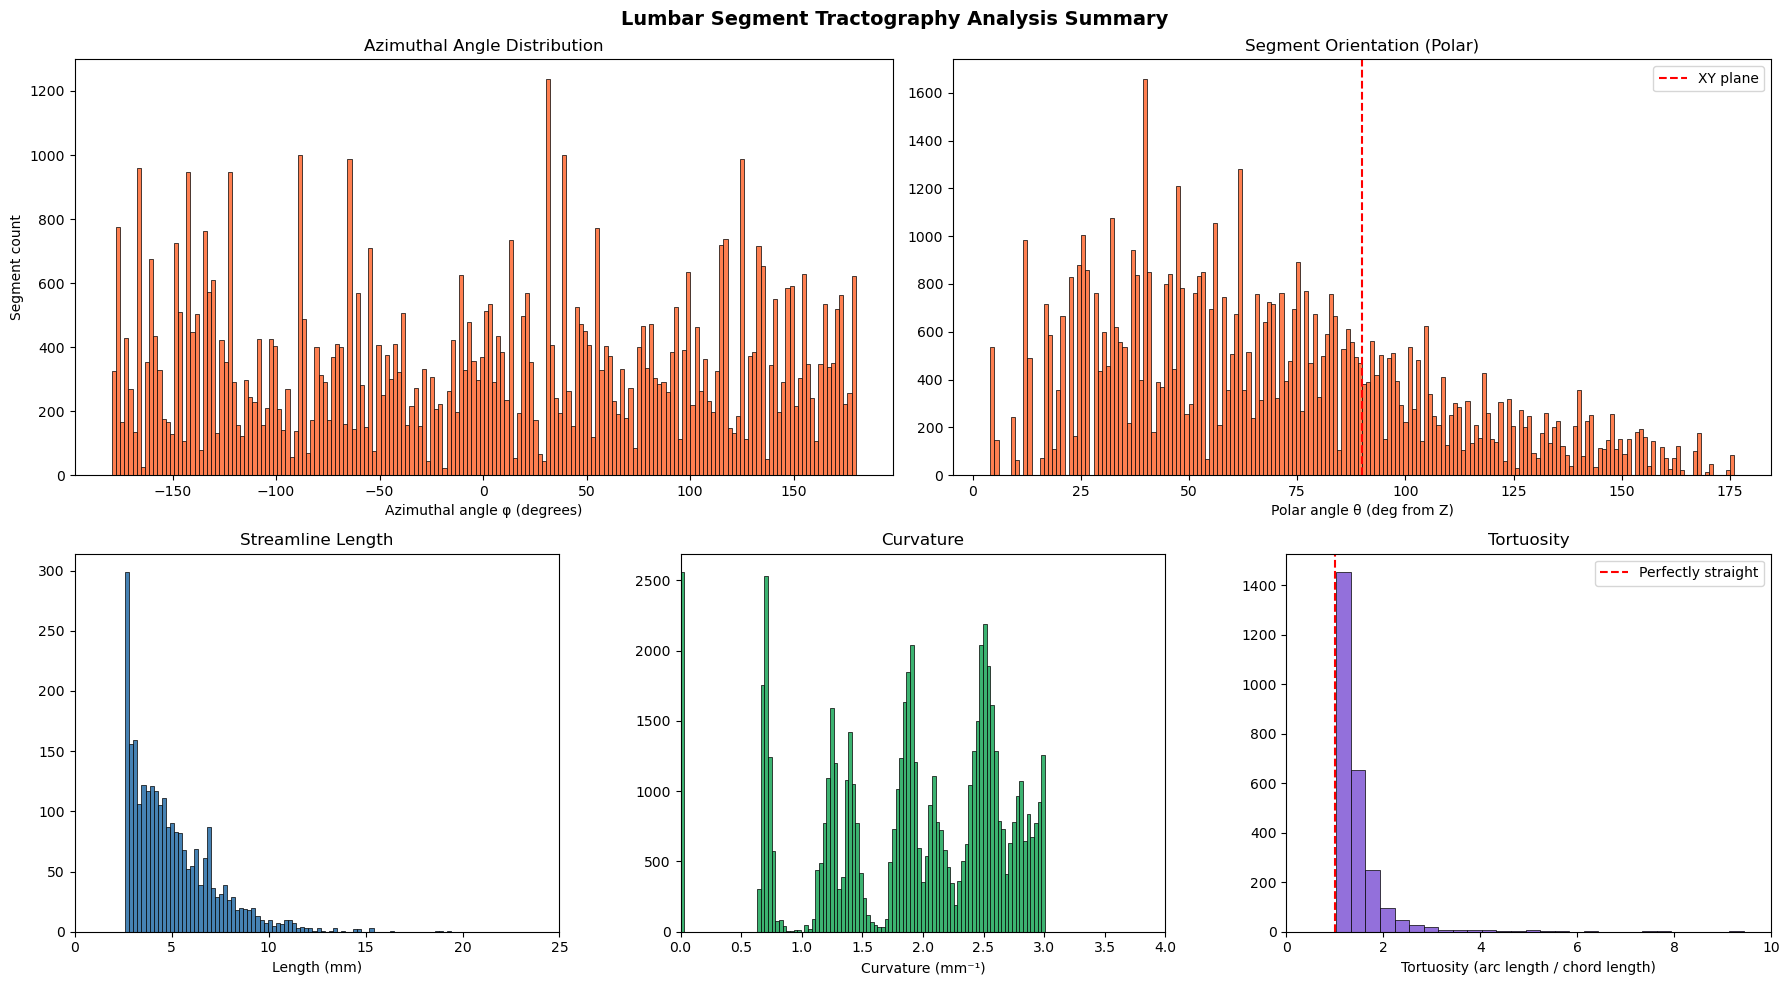

Number of streamlines:  1474
Mean length:            4.67 mm
Median length:          4.20 mm
Min length:             2.60 mm
Max length:             17.40 mm
Std length:             1.88 mm
Streamlines after length filter: 1474

Mean segment direction (unit): [-0.19010856 -0.09204007  0.97743919]

Mean curvature:   1.9162 mm^-1
Median curvature: 1.9874 mm^-1

Mean tortuosity:   1.463
Median tortuosity: 1.284


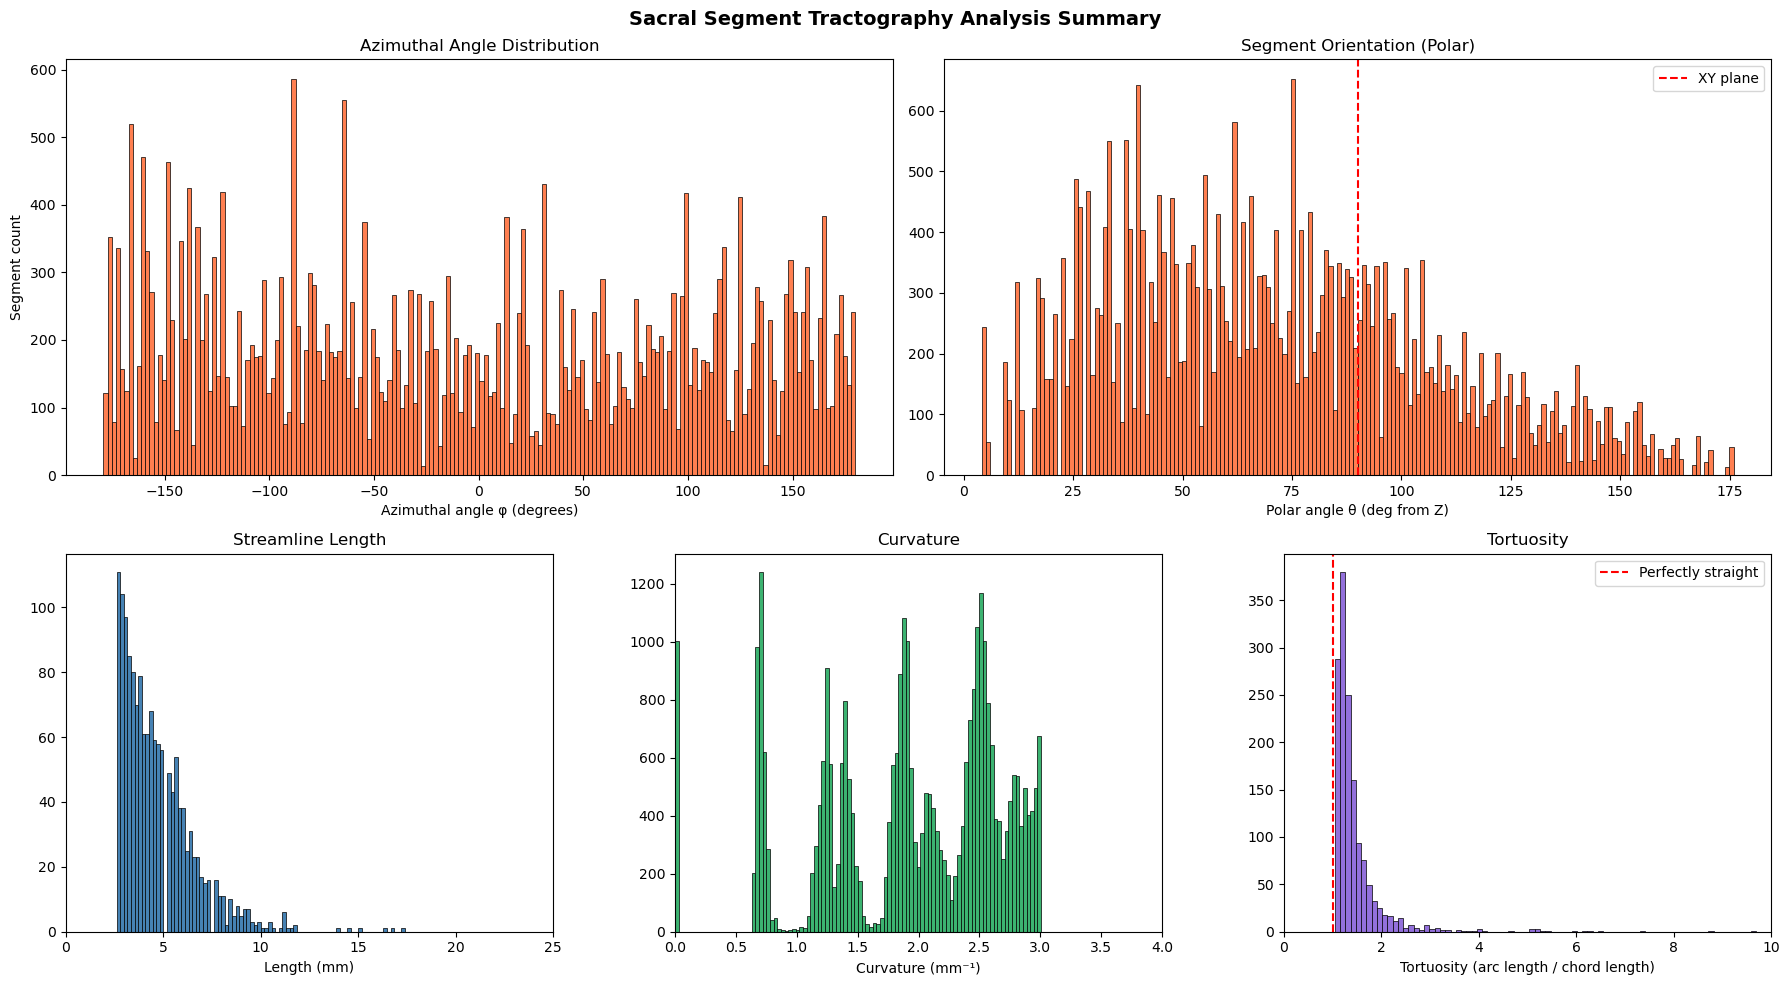

In [142]:
visualize_streamlines_stats(filtered_streamlines = length_filtered_streamlines_seed_filtered_cervical, filtered_lengths= lengths_cervical,
                            plot_each= False, summary_title="Cervical Segment Tractography Analysis Summary", 
                            fig_save_path="Figures/Tractography/Tractography_Summary_Cervical.svg")


visualize_streamlines_stats(filtered_streamlines = length_filtered_streamlines_seed_filtered_thoracic, filtered_lengths= lengths_thoracic,
                            plot_each= False, summary_title="Thoracic Segment Tractography Analysis Summary", 
                            fig_save_path="Figures/Tractography/Tractography_Summary_Thoracic.svg")

visualize_streamlines_stats(filtered_streamlines = length_filtered_streamlines_seed_filtered_lumbar, filtered_lengths= lengths_lumbar,
                            plot_each= False, summary_title="Lumbar Segment Tractography Analysis Summary",
                            fig_save_path="Figures/Tractography/Tractography_Summary_Lumbar.svg")

visualize_streamlines_stats(filtered_streamlines = length_filtered_streamlines_seed_filtered_sacral, filtered_lengths= lengths_sacral,
                            plot_each= False, summary_title="Sacral Segment Tractography Analysis Summary",
                            fig_save_path="Figures/Tractography/Tractography_Summary_Sacral.svg")